In [2]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
import ast
df['job_skills'] = df['job_skills'].apply( lambda job_skills : ast.literal_eval(job_skills ) if pd.notna(job_skills) else job_skills )

In [3]:
df_de = df[ df['job_title_short'] == 'Data Engineer' ].copy()

df_exploded = df_de.explode('job_skills')
df_exploded

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,python,"{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,sql,"{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,c#,"{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,azure,"{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,airflow,"{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,spark,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,hadoop,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kafka,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kubernetes,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [4]:
df_agg1 = df_exploded.groupby('job_skills').agg(
    skill_count = ( 'job_skills' ,'count'),
    median_salary = ( 'salary_year_avg','median')
)
df_agg2 = df_agg1.sort_values( 'skill_count' , ascending= False).head(20)

df_agg2

,skill_count,median_salary
job_skills,,
sql,113130,125000.0
python,108022,125000.0
aws,62049,130000.0
azure,60674,125000.0
spark,53656,134775.0
java,35559,134241.0
kafka,29073,140000.0
hadoop,28815,134241.0
scala,28716,137500.0


In [5]:
from adjustText import adjust_text;

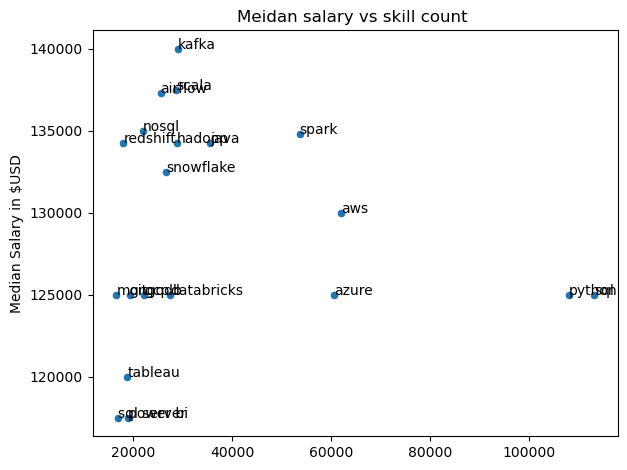

In [6]:
df_agg3 = df_agg2.plot(kind='scatter' , x= 'skill_count' , y = 'median_salary' )
plt.title("Meidan salary vs skill count ")
plt.ylabel("Median Salary in $USD")
plt.xlabel("")

txt = []
for i , text in enumerate(df_agg2.index):
    plt.text(df_agg2['skill_count'].iloc[i], df_agg2['median_salary'].iloc[i], text)
    
plt.tight_layout()
plt.show()



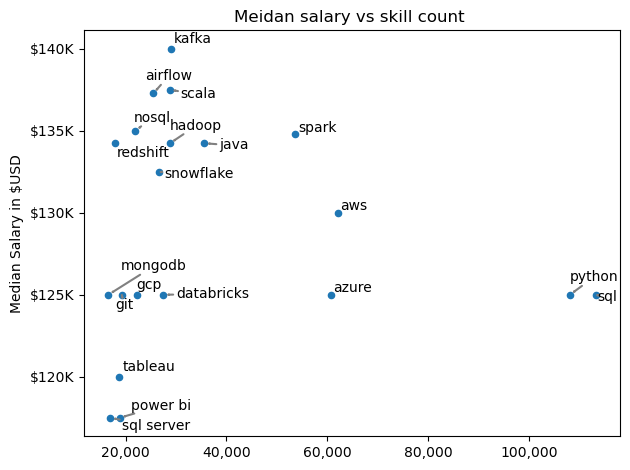

In [7]:
df_agg4 = df_agg2.plot(kind='scatter' , x= 'skill_count' , y = 'median_salary' )
plt.title("Meidan salary vs skill count ")
plt.ylabel("Median Salary in $USD")
plt.xlabel("")

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos : f'${int(y/1000)}K' ))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _ : f'{int(x):,}' ))

texts = []
for i , text in enumerate(df_agg2.index):
    texts.append(plt.text(df_agg2['skill_count'].iloc[i], df_agg2['median_salary'].iloc[i], text))


adjust_text(texts, arrowprops=dict(arrowstyle="->" , color= 'grey', lw=1.5 ) )
plt.tight_layout()
plt.show()



Text(0.5, 0, 'yearly salary')

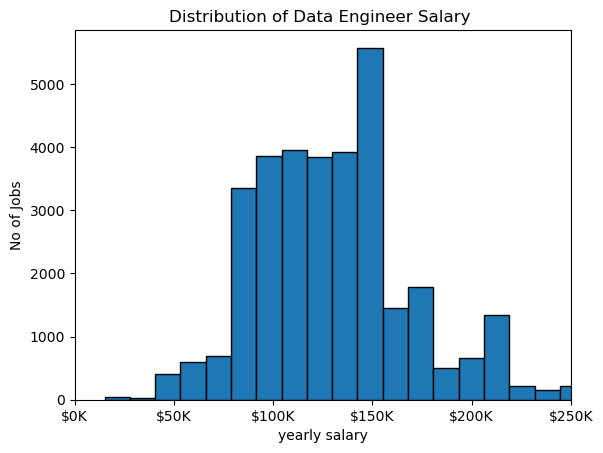

In [8]:
df_exploded['salary_year_avg'].plot(kind='hist', bins= 40, edgecolor='black')

plt.xlim(0,250000)

ax = plt.gca()

ax.xaxis.set_major_formatter(plt.FuncFormatter (lambda x,_ : f'${int(x/1000):,}K' ))

plt.title("Distribution of Data Engineer Salary ")
plt.ylabel("No of Jobs")
plt.xlabel("yearly salary")


In [18]:
import seaborn as sns

Text(0.5, 9.444444444444438, 'yearly salary')

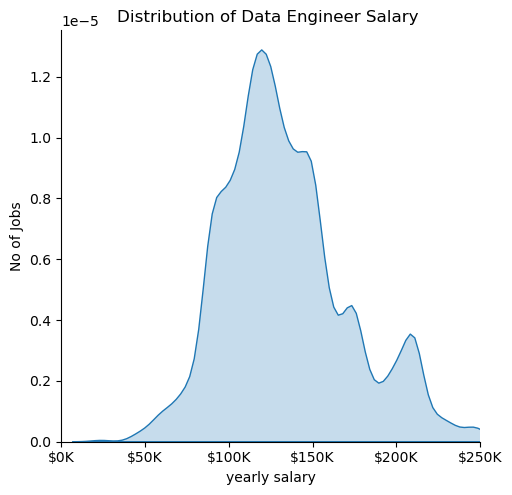

In [ ]:
df_exploded_g = df_exploded[df_exploded['job_country'] == 'United States']

sns.displot( df_exploded_g['salary_year_avg'], kind ='kde' , fill = True)
#df_exploded['salary_year_avg'].plot(kind='hist', bins= 40, edgecolor='black')

plt.xlim(0,250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter (lambda x,_ : f'${int(x/1000):,}K' ))
plt.title("Distribution of Data Engineer Salary ")
plt.ylabel("No of Jobs")
plt.xlabel("yearly salary")

Text(0.5, 9.444444444444438, 'yearly salary')

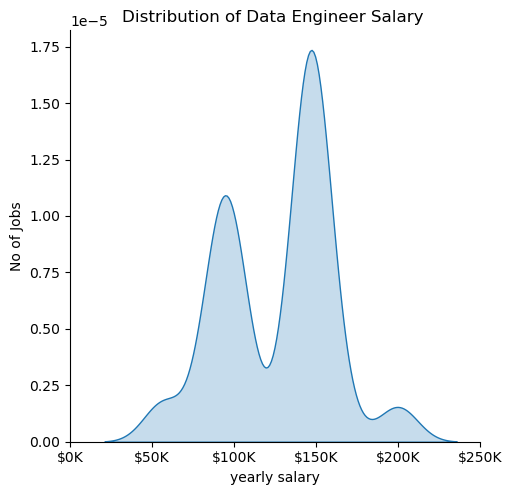

In [23]:
df_exploded_g = df_exploded[df_exploded['job_country'] == 'Germany']
sns.displot( df_exploded_g['salary_year_avg'], kind ='kde' , fill = True)
#df_exploded['salary_year_avg'].plot(kind='hist', bins= 40, edgecolor='black')
plt.xlim(0,250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter (lambda x,_ : f'${int(x/1000):,}K' ))
plt.title("Distribution of Data Engineer Salary ")
plt.ylabel("No of Jobs")
plt.xlabel("yearly salary")


In [10]:
df_ge = df_de[df['job_country'] == 'Germany']
df_ge = df_ge.dropna(subset= 'salary_year_avg')
df_ge['salary_year_avg'].sample(10)

/var/folders/qh/cv5734q97_n7gd9__8jl03mw0000gr/T/ipykernel_62380/758890490.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ge = df_de[df['job_country'] == 'Germany']


45652     147500.0
435957     89100.0
486217    131580.0
563324     56700.0
452679     98301.5
459018    140000.0
391155     56700.0
257651     56700.0
247392    147500.0
547988     97444.0
Name: salary_year_avg, dtype: float64

<Axes: >

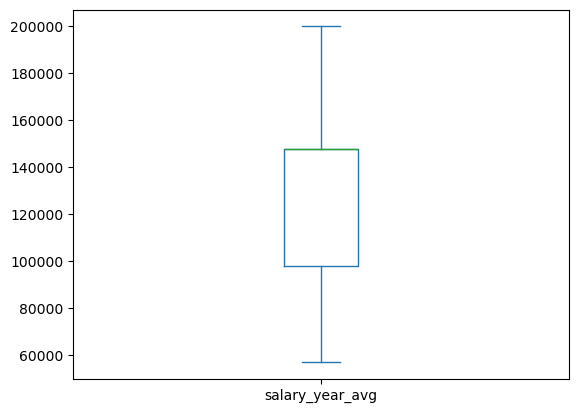

In [11]:
df_ge['salary_year_avg'].plot(kind='box')

{'whiskers': [<matplotlib.lines.Line2D at 0x352914c90>,
 'caps': [<matplotlib.lines.Line2D at 0x352915ed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x3528c9e50>],
 'medians': [<matplotlib.lines.Line2D at 0x352917550>],
 'fliers': [<matplotlib.lines.Line2D at 0x35291c050>],
 'means': []}

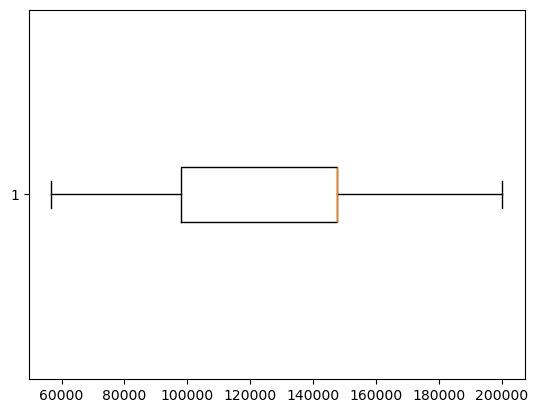

In [12]:
plt.boxplot(df_ge['salary_year_avg'],vert=False)

In [13]:
df['job_title_short'].value_counts()

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

/var/folders/qh/cv5734q97_n7gd9__8jl03mw0000gr/T/ipykernel_62380/676307238.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list,labels=job_titles, vert=False)


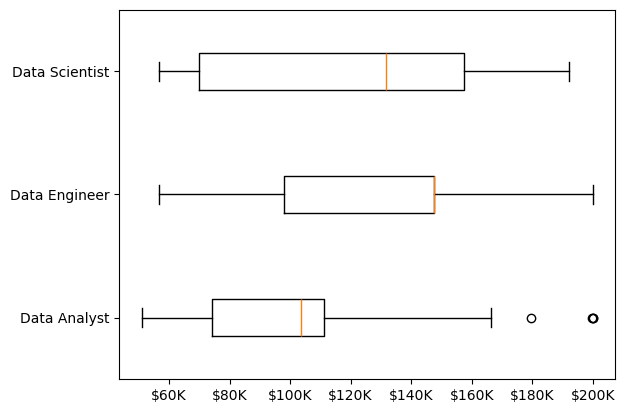

In [14]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist' ]

df_ge1 = df[ 
    (df['job_title_short'].isin(job_titles)) & 
    (df['job_country'] == 'Germany')
    ].copy()
df_ge1 = df_ge1.dropna( subset=['salary_year_avg'])

job_list = [ df_ge1[df_ge1['job_title_short'] == job]['salary_year_avg']  for job in job_titles ]


plt.boxplot(job_list,labels=job_titles, vert=False)

ax = plt.gca()

ax.xaxis.set_major_formatter( plt.FuncFormatter(lambda x , _ :f'${int(x/1000)}K') )

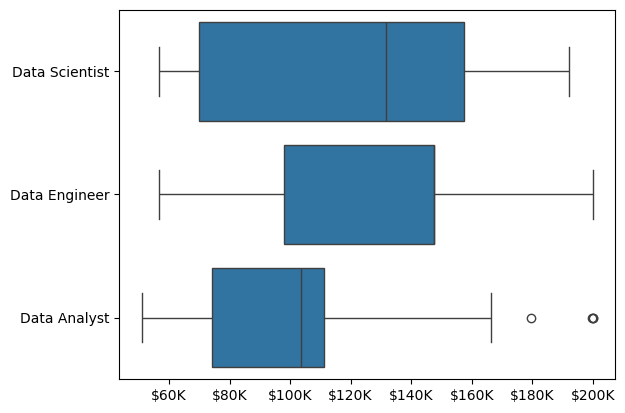

In [29]:
sns.boxplot(data = df_ge1 , x= 'salary_year_avg' , y = 'job_title_short')
plt.ylabel('')
plt.xlabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter( plt.FuncFormatter(lambda x , _ :f'${int(x/1000)}K') )

In [15]:
df_ge1['job_title_short'].value_counts()

job_title_short
Data Analyst      48
Data Scientist    41
Data Engineer     39
Name: count, dtype: int64

In [16]:
df_ge1['salary_year_avg'].sample(10)

655159    111175.0
754794    111202.0
576109     92000.0
714049    200000.0
547988     97444.0
745711    165000.0
753636    147500.0
119182    157500.0
57582      89100.0
417666     89100.0
Name: salary_year_avg, dtype: float64

/var/folders/qh/cv5734q97_n7gd9__8jl03mw0000gr/T/ipykernel_62380/2397171979.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_lists1,labels=job_titles, vert=False)


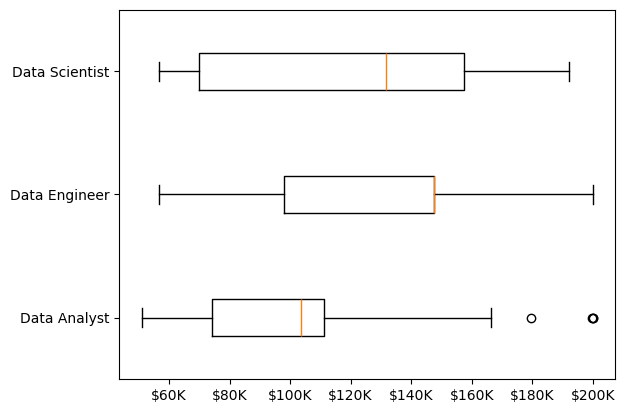

In [17]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist' ]

df_ge3 = df[ 
    (df['job_title_short'].isin(job_titles)) & 
    (df['job_country'] == 'United States')
    ].copy()
df_ge3 = df_ge1.dropna( subset=['salary_year_avg'])

job_lists1 = [ df_ge1[df_ge1['job_title_short'] == job]['salary_year_avg']  for job in job_titles ]

plt.boxplot(job_lists1,labels=job_titles, vert=False)

ax = plt.gca()

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_ : f'${int(x/1000)}K') )

